## 주식예측 모델 만들기 (LSTM)

In [ ]:
#!pip install numpy pandas scikit-learn matplotlib yfinance
# yfinance: Yahoo Finance에서 주식 데이터를 가져오는 라이브러리
!pip install yfinance

#### 주가 데이터 수집

In [82]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

# 삼성전자 데이터
symbol = '005930.KQ'
stock = yf.Ticker(symbol)
df = stock.history(period='5y')  # 최근 5년치 데이터
df = df[['Close']]           # 종가
df.dropna(inplace=True)

#### MinMaxScaler로 데이터 정규화

In [83]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

#### 시퀀스 데이터셋 생성

In [84]:
window = 60 # 60일치 데이터로 다음 날 예측
X, Y = [], []
for i in range(window, len(scaled)):
    X.append(scaled[i-window:i, 0])
    Y.append(scaled[i, 0])
X = np.array(X)
Y = np.array(Y)

#### 학습/테스트 데이터 분할 (시계열 유지, shuffle=False 권장)

In [85]:
# 데이터셋 분할 (80% 훈련, 20% 테스트)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, shuffle=False)

X_train = X_train.reshape(-1, window, 1)
X_test = X_test.reshape(-1, window, 1)
print(X_train.shape, X_test.shape)

(931, 60, 1) (233, 60, 1)


#### LSTM 모델 구조 및 학습

In [86]:
from tensorflow.keras import Input, Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(Input(shape=(window, 1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))

In [87]:
# 조기 종료 콜백
ealry_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 학습용, 검증용 데이터셋 분리 및 모델 학습
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train, Y_train, epochs=100, batch_size=16, verbose=1, validation_split=0.1, callbacks=[ealry_stopping])

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0196 - mae: 0.0932 - val_loss: 0.0127 - val_mae: 0.0909
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0037 - mae: 0.0444 - val_loss: 0.0102 - val_mae: 0.0814
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0031 - mae: 0.0415 - val_loss: 0.0079 - val_mae: 0.0730
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0027 - mae: 0.0377 - val_loss: 0.0071 - val_mae: 0.0687
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0025 - mae: 0.0370 - val_loss: 0.0060 - val_mae: 0.0634
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0023 - mae: 0.0353 - val_loss: 0.0057 - val_mae: 0.0609
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0020 - mae: 0.0339 - val_loss: 0.0050 - val_mae: 0.0565
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0019 - mae: 0.0325 - val_loss: 0.0049 - val_mae: 0.0548
Epoch 9/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - lo

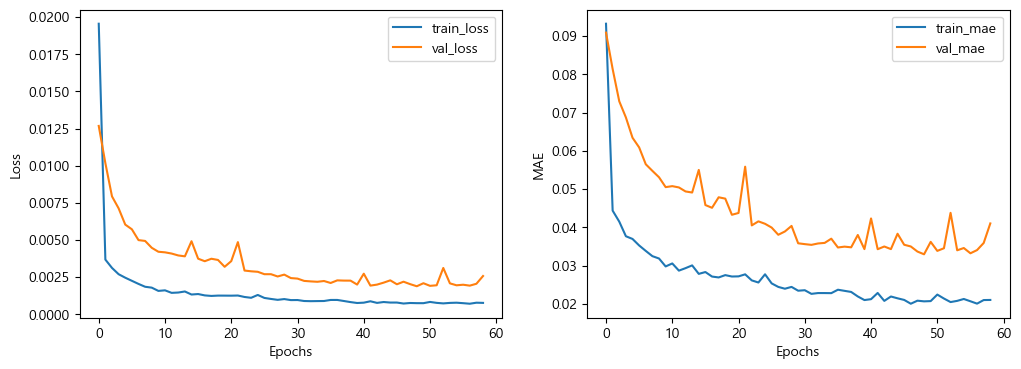

In [88]:
# 성능지표 그래프
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='train_mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

# loss 의미: 예측값과 실제값의 차이를 제곱하여 평균한 값 (작을수록 좋음)
# MAE 의미: 예측값과 실제값의 차이의 절대값을 평균한 값 (작을수록 좋음)

#### 예측 및 평가

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
평균 절대 오차(MAE): 974.24 원
R^2: 0.96


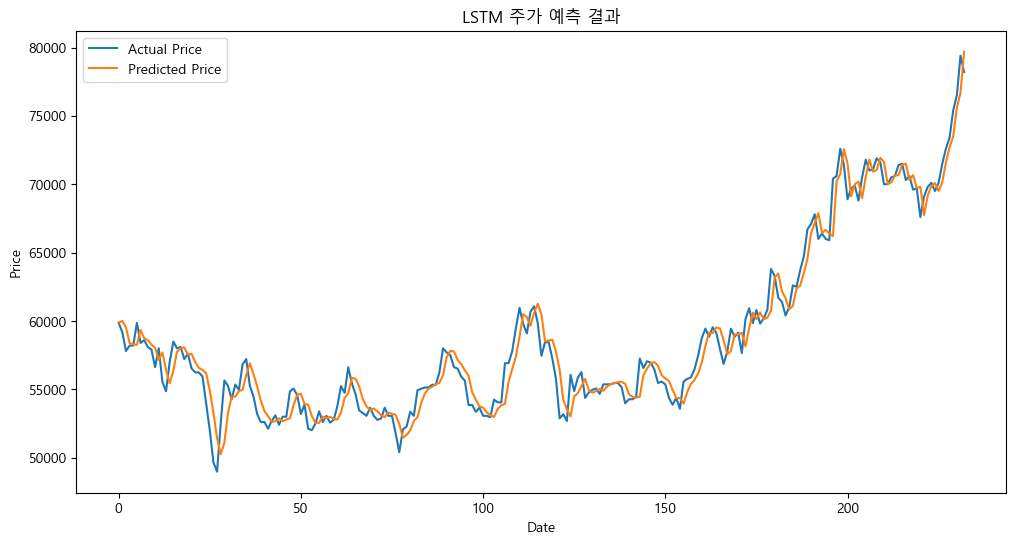

In [89]:
# 예측 결과
Y_pred = model.predict(X_test)

# 실제 가격 복원
Y_test_inv = scaler.inverse_transform(Y_test.reshape(-1, 1))
Y_pred_inv = scaler.inverse_transform(Y_pred)

# 평가 (MAE)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(Y_test_inv, Y_pred_inv)
print(f"평균 절대 오차(MAE): {mae:.2f} 원")

# 평가 (R2)
from sklearn.metrics import r2_score
r2 = r2_score(Y_test_inv, Y_pred_inv)
print(f"R^2: {r2:.2f}")

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기본 한글 폰트
mpl.rcParams['axes.unicode_minus'] = False    # 마이너스 기호 정상 출력

# 시각화
plt.figure(figsize=(12,6))
plt.plot(Y_test_inv, label='Actual Price')
plt.plot(Y_pred_inv, label='Predicted Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.title('LSTM 주가 예측 결과')
plt.show()


In [90]:
# 3일 예측
f_days = 3
def rolling_forecast(model, initial_sequence, scaler, steps=3):
    cur_seq = initial_sequence.copy()
    preds = []

    for _ in range(steps):
        input_seq = cur_seq.reshape(1, cur_seq.shape[0], 1)
        pred_scaled = model.predict(input_seq)
        pred_price = scaler.inverse_transform(pred_scaled)[0,0]
        preds.append(pred_price)
        pred_scaled_reshaped = pred_scaled.reshape(1,1)
        cur_seq = np.append(cur_seq[1:], pred_scaled_reshaped, axis=0)

    return preds

initial_seq = X_test[-1]
future_preds = rolling_forecast(model, initial_seq, scaler, steps=f_days)

print("향후 3일 예측 종가:")
for i, price in enumerate(future_preds, 1):
    print(f"{(df.index[-1] + pd.Timedelta(days=i)).date()}: {price:.2f} 원")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
향후 3일 예측 종가:
2025-09-18: 79693.12 원
2025-09-19: 79806.45 원
2025-09-20: 79987.63 원


In [91]:
from joblib import dump
dump(model, 'model.pkl')


['model.pkl']